# Esophageal Cancer Detection with Images

## Introduction

This notebook implements a binary classifier for detecting esophageal cancer from medical images. The dataset used in this project was supplied by **Mauna Kea Technologies**, a company specialized in real-time cellular imaging through probe-based confocal laser endomicroscopy (pCLE).

The challenge can be found in the following [URL](https://challengedata.ens.fr/challenges/11).

The goal is to build a model capable of distinguishing between cancerous and non-cancerous tissue samples from endoscopic images, aiding in the early detection and diagnosis of esophageal cancer.

In [1]:
import os
import zipfile

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from skimage.io import imread
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.linear_model import Perceptron

In [2]:
filepath = os.path.join(
    os.getcwd(), "..", "data", "cancer_images", "imagenes_260x260.zip"
)

filename = os.path.join(
    os.getcwd(), "..", "data", "cancer_images", "ClasesImagenes.csv"
)

In [3]:
# extract the zip file
with zipfile.ZipFile(filepath, "r") as zip_ref:
    zip_ref.extractall(os.path.join(os.getcwd(), "..", "data", "cancer_images"))

In [4]:
# read the csv file
df = pd.read_csv(filename)
df.head()

,Unnamed: 0,image_filename,class_number
0,0,im_4_0.png,0
1,1,im_21_0.png,0
2,2,im_9_0.png,0
3,3,im_8_0.png,0
4,4,im_15_0.png,0


In [5]:
# read the files in the csv file and create a np.ndarray
png_filepath = os.path.join(os.getcwd(), "..", "data", "cancer_images")
img = df["image_filename"].apply(lambda x: imread(os.path.join(png_filepath, f"{x}")))

In [6]:
# size of the images
img.shape

(5063,)

In [7]:
# stack the images in a np.ndarray
dataset_x = np.stack(img, axis=0)  # type: ignore
dataset_x.shape

(5063, 260, 260)

In [8]:
# get the class labels
dataset_y = df["class_number"]
dataset_y.shape

(5063,)

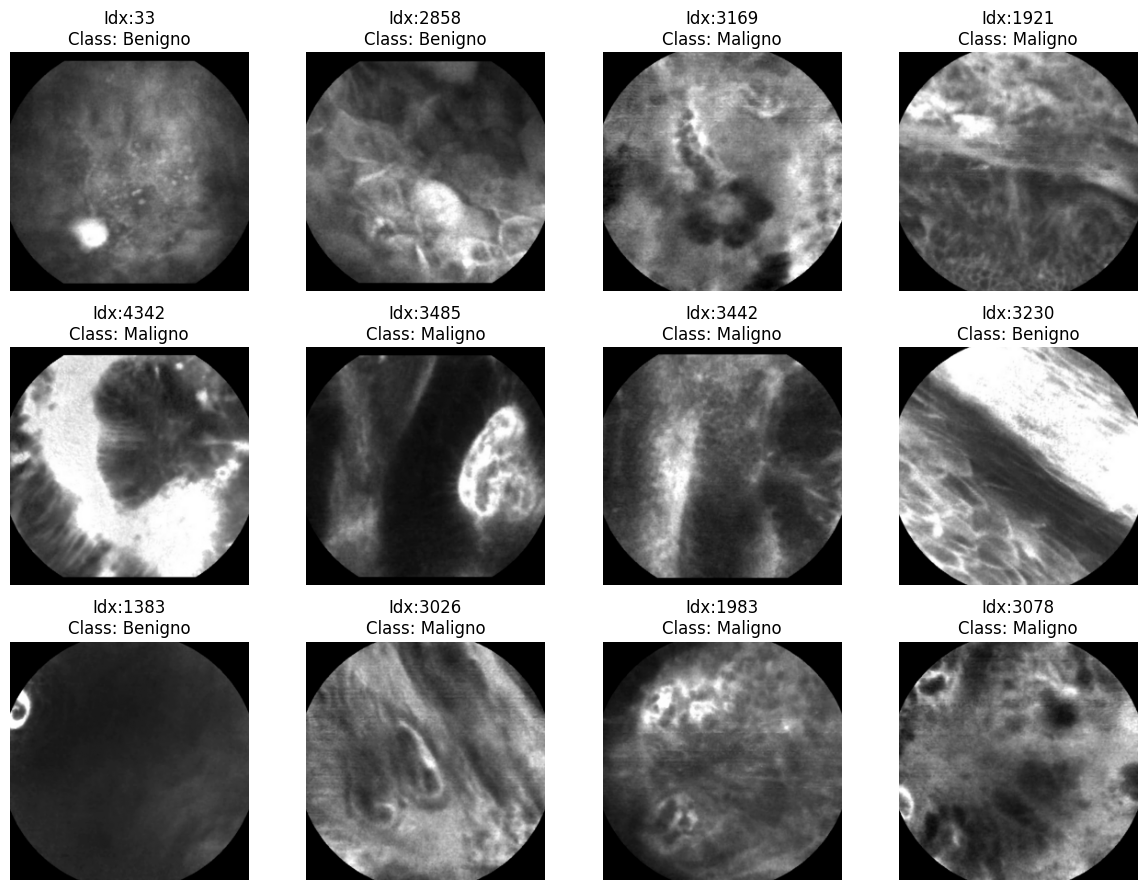

In [9]:
# graph a sample of the images with their class labels
N = 12
indices = df.sample(n=min(N, len(df)), random_state=42).index.tolist()
cols = 4
rows = int(np.ceil(len(indices) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()

labels = {0: "Benigno", 1: "Maligno"}

for ax, idx in zip(axes, indices):
    ax.imshow(dataset_x[idx], cmap="gray")
    ax.set_title(f"Idx:{idx}\nClass: {labels[dataset_y[idx]]}")
    ax.axis("off")

for ax in axes[len(indices) :]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# reshape the dataset to be 2D (n_samples, n_features)
dataset_x.reshape(260**2, -1).T.shape

(5063, 67600)

In [11]:
# create a train-test split of the dataset
Xtrain, Xtest, ytrain, ytest = train_test_split(
    dataset_x.reshape(260**2, -1).T,
    dataset_y,
    test_size=0.3,
    random_state=0,
    stratify=dataset_y,
    shuffle=True,
)

In [12]:
# create the Perceptron model and fit it to the training data
model1 = Perceptron(
    random_state=42,
    max_iter=1000,
    verbose=True,
    n_jobs=-1,
    tol=1e-3,
).fit(Xtrain, ytrain)

# create the Perceptron model with L2 regularization and fit it to the training data
model2 = Perceptron(
    random_state=42,
    max_iter=1000,
    penalty="l2",
    alpha=1e-10,
    verbose=True,
    n_jobs=-1,
    tol=1e-3,
).fit(Xtrain, ytrain)

-- Epoch 1
Norm: 335117.85, NNZs: 67554, Bias: 1.000000, T: 3544, Avg. loss: 101717700.890801, Objective: 101717700.890801
Total training time: 0.19 seconds.
-- Epoch 2
Norm: 499373.99, NNZs: 67555, Bias: 0.000000, T: 7088, Avg. loss: 75847992.690463, Objective: 75847992.690463
Total training time: 0.38 seconds.
-- Epoch 3
Norm: 655646.02, NNZs: 67581, Bias: 1.000000, T: 10632, Avg. loss: 59772592.547404, Objective: 59772592.547404
Total training time: 0.56 seconds.
-- Epoch 4
Norm: 789862.89, NNZs: 67579, Bias: 1.000000, T: 14176, Avg. loss: 52999732.394752, Objective: 52999732.394752
Total training time: 0.74 seconds.
-- Epoch 5
Norm: 908945.27, NNZs: 67584, Bias: 1.000000, T: 17720, Avg. loss: 47062393.849887, Objective: 47062393.849887
Total training time: 0.91 seconds.
-- Epoch 6
Norm: 1007610.16, NNZs: 67587, Bias: 1.000000, T: 21264, Avg. loss: 40213032.220655, Objective: 40213032.220655
Total training time: 1.08 seconds.
-- Epoch 7
Norm: 1098708.29, NNZs: 67581, Bias: 1.000000,

In [13]:
# evaluate the model on the test set
acc1 = model1.score(Xtest, ytest)
acc2 = model2.score(Xtest, ytest)

print(f"Accuracy of the Perceptron model without regularization: {acc1:.4f}")
print(f"Accuracy of the Perceptron model with L2 regularization: {acc2:.4f}")

Accuracy of the Perceptron model without regularization: 0.9822
Accuracy of the Perceptron model with L2 regularization: 0.9085


In [14]:
# predict the class labels for the test set
y1_pred = model1.predict(Xtest)
y2_pred = model2.predict(Xtest)

In [15]:
def create_confusion_plot(ytest, ypred):
    pred_df = pd.DataFrame({"Real": ytest, "Predicted": ypred})

    # create the confusion matrix
    confusion_matrix = pd.crosstab(pred_df["Real"], pred_df["Predicted"])

    # display the confusion matrix as a heatmap
    fig, ax = plt.subplots(figsize=(4, 3))
    _ = sns.heatmap(confusion_matrix, annot=True, fmt="g", ax=ax)

              precision    recall  f1-score   support

           0       0.99      0.95      0.97       441
           1       0.98      1.00      0.99      1078

    accuracy                           0.98      1519
   macro avg       0.99      0.97      0.98      1519
weighted avg       0.98      0.98      0.98      1519



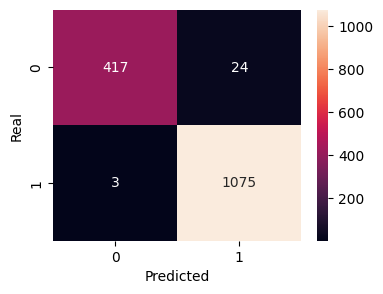

In [16]:
# display the classification report
report = classification_report(ytest, y1_pred)
print(report)

create_confusion_plot(ytest, y1_pred)

              precision    recall  f1-score   support

           0       0.76      1.00      0.86       441
           1       1.00      0.87      0.93      1078

    accuracy                           0.91      1519
   macro avg       0.88      0.94      0.90      1519
weighted avg       0.93      0.91      0.91      1519



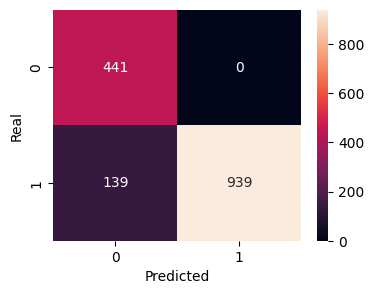

In [17]:
# display the classification report
report = classification_report(ytest, y2_pred)
print(report)

create_confusion_plot(ytest, y2_pred)